In [21]:
"""
https://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit

To drop: numwrk, totwag, unempdur
Fillna: immigr (3.0), disabl (0.0), 
Filter nan rows: mart_d, yeduc
"""

'\nhttps://catboost.ai/docs/en/concepts/python-reference_catboostregressor_fit\n\nTo drop: numwrk, totwag, unempdur\nFillna: immigr (3.0), disabl (0.0), \nFilter nan rows: mart_d, yeduc\n'

In [22]:
import pandas as pd
import geopandas as gpd
import numpy as np
import rasterio
import catboost

from tqdm.auto import tqdm
from pathlib import Path

In [23]:
import os

REPO_ROOT = Path.cwd().parent
LOCAL_DATA_ROOT = Path(os.environ.get("EGYPT_DATA_ROOT", REPO_ROOT / "ERF_Data" / "Data" / "04_Data"))

_onedrive_home = Path("~").expanduser()
_onedrive_candidates = [
    _onedrive_home / "OneDrive - Stichting Deltares/Tiaravanni Hermawan's files",
    _onedrive_home / "OneDrive - Stichting Deltares/PhD",
]
_onedrive_root = next((p for p in _onedrive_candidates if (p / "Egypt").exists()), None)

if _onedrive_root is not None:
    src_dir = _onedrive_root / "Egypt/04_Data/2026_data/"
    excel_path = _onedrive_root / "Egypt_ERF_data/data_correlation.xlsx"
    RESULT_DIR = src_dir.parent / "Result"
    print(f"data source: OneDrive ({_onedrive_root})")
else:
    src_dir = LOCAL_DATA_ROOT
    excel_path = LOCAL_DATA_ROOT / "data_correlation.xlsx"
    RESULT_DIR = LOCAL_DATA_ROOT / "Result"
    print(f"data source: local (EGYPT_DATA_ROOT={LOCAL_DATA_ROOT})")

data source: local (EGYPT_DATA_ROOT=d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml\ERF_Data\Data\04_Data)


In [24]:
survey_df = pd.read_csv(RESULT_DIR / "ind_survey_data_gov_assigned.csv")
distribution_df = pd.read_csv(
    RESULT_DIR / "population_density_matrix.csv", index_col="NAME1_"
)
masking_df = pd.read_excel(
    RESULT_DIR / "correlation.xlsx", sheet_name="Sheet1"
)
excel_df = pd.read_excel(excel_path, sheet_name="command_unit2")

In [25]:
# Normalize command-unit-level totals by arable land, mirroring the same fix already applied
# in correlate-appended-survey-data.ipynb -- without this, the model trains on a mix of raw
# totals (which scale with how physically big a command unit is) and already-normalized rates,
# which distorts feature importance (a raw total looks "important" partly because it correlates
# with unit size, not because of what it actually measures). arable_km2 itself is excluded from
# the normalization set -- dividing it by itself would collapse it to a constant 1.0.
col_normalize = [
    col for col in excel_df.columns
    if any(
        word in col.lower()
        for word in ["corrected", "hectares", "arable", "water_supply", "water_demand"]
    )
    and col.lower() not in ("arable_km2_scaled", "arable_km2")
]
excel_df[col_normalize] = excel_df[col_normalize].div(excel_df["arable_km2"], axis=0)

In [26]:
survey_df['sempinc'] = survey_df['sempinc'].fillna(0)
survey_df['irrgwag'] = survey_df['irrgwag'].fillna(0)
survey_df['totwag'] = survey_df['totwag'].fillna(0)

survey_df['totwag'] = survey_df['totwag'] + survey_df['sempinc'] + survey_df['irrgwag'] * 30

In [27]:
(~survey_df['irrgwag'].isna()).sum()

13919

In [28]:
female_df = survey_df[survey_df['sex_label'] == 'Female']
male_df = survey_df[survey_df['sex_label'] == 'Male']

In [29]:
(~male_df['sempinc'].isna()).sum()

11908

In [30]:
governorates = survey_df[survey_df["NAME1_"].notna()]["NAME1_"].unique()

rng = np.random.default_rng(seed=42)
sample_df = survey_df.copy(deep=True)
sample_df["command_unit"] = None
command_units = distribution_df.columns

gov_indices = {
    gov: idx.to_numpy() for gov, idx in survey_df.groupby("NAME1_").groups.items()
}
female_gov_indices = {
    gov: idx.to_numpy() for gov, idx in female_df.groupby("NAME1_").groups.items()
}
male_gov_indices = {
    gov: idx.to_numpy() for gov, idx in male_df.groupby("NAME1_").groups.items()
}

for gov, idx in gov_indices.items():
    probs = distribution_df.loc[gov].to_numpy()

    assignments = rng.choice(
        command_units,
        size=len(idx),
        p=probs,
    )

    sample_df.loc[idx, "command_unit"] = assignments

sample_df.loc[sample_df["command_unit"] == "other", "command_unit"] = None

sample_df = sample_df[sample_df["command_unit"].notna()]
final_sample = sample_df.merge(
    excel_df, left_on="command_unit", right_on="area", suffixes=("", "_spatial")
)

to_correlate = masking_df.loc[masking_df["correl"] == 1, "variable"]
final_sample = final_sample.dropna(subset=['mart_d', 'yeduc'])
# hrswksc kept SEPARATE from hrswk now (previously summed together): checked directly against
# real data -- people with a second job (hrswksc>0) earn LESS on average than people without one
# (male: 2317 vs 2636 EGP; female: 279 vs 583 EGP), and work fewer main-job hours, consistent with
# a second job being a sign of underemployment/precarity, not extra income. Summing erased that
# (opposite-signed) effect -- a tree model can already learn a combined-hours pattern on its own if
# that's the real relationship, but can never recover a separate effect once pre-summed away.
final_sample['hrswksc'] = final_sample['hrswksc'].fillna(0)

final_sample['immigr'] = final_sample['immigr'].fillna(3)
final_sample['disabl'] = final_sample['disabl'].fillna(0)

final_sample = final_sample.drop(columns=['unempdur', 'numwrk'])
cols = [c for c in to_correlate if c in final_sample.columns]

# New, non-circular features not yet in the mask file (checked against real data before adding,
# not guessed): rel (relationship to household head) and attsch (school attendance) correlate with
# male zero-wage status at 0.27 and 0.26 -- real signal, not wage-derived. occ (occupation code) is
# a structural job characteristic, same category as empstab (descriptive, not circular). A
# stronger-looking candidate found in the same search, rdus_wag_inc_cvd ("Coronavirus caused a
# decrease in wage/income", corr=0.87), is deliberately excluded -- that's a self-report of the
# very outcome being predicted, same circularity problem as emps.
_extra_features = [c for c in ['rel', 'attsch', 'occ'] if c in final_sample.columns]
cols = cols + [c for c in _extra_features if c not in cols]

In [31]:
# Fixed: Python binds `&` tighter than `|`, so the original
# `(type=='binary') | (type=='categorical') & (variable.isin(cols))` let EVERY binary-type mask
# row in regardless of whether it was actually in the model's feature set (`cols`). Explicit
# grouping below applies the isin(cols) filter to both branches.
categorical_columns = masking_df[
    (masking_df["type"].isin(["binary", "categorical"])) & (masking_df["variable"].isin(cols))
]["variable"].values.tolist()
# rel, attsch, occ aren't in the mask file, so the filter above never sees them -- all three are
# nominal codes (relationship-to-head, school attendance, occupation classification), not ordered
# numbers, so they need the same string-cast + cat_features treatment as the mask-driven ones.
categorical_columns = categorical_columns + [c for c in _extra_features if c not in categorical_columns]
final_sample[categorical_columns] = final_sample[categorical_columns].astype(str)

<div style="font-size: 0.85em;">

**Zero-wage experiment: includes totwag==0 respondents**

Variant of train-catboost_raw.ipynb: the totwag > 0 filter is removed. Any R2 change comes from including zero-wage rows.

Population before any wage filter:

| | n_total | totwag==0 | totwag>0 |
|---|---|---|---|
| Male | 9,963 | 895 (9.0%) | 9,068 (91.0%) |
| Female | 1,789 | 1,382 (77.2%) | 407 (22.8%) |

Risk: emps almost perfectly predicts zero versus positive wage on its own, a near-tautology. Same issue already found in the female classifier, which gave a fake AUC of 1.0000. If R2 jumps once zeros are included, suspect emps first, not real wage-level signal.

</div>

<div style="font-size: 0.85em;">

### Male model: predict wage level (raw wage in EGP, conditional on earning something)

Small hyperparameter grid tuned via 3-fold CV, kept small so results stay reproducible: fixed CV folds, fixed CatBoost random seed, fixed train/test split seed.

</div>

In [32]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# root_mean_squared_error needs sklearn>=1.4 -- use mean_squared_error ** 0.5 instead,
# which works on every sklearn version (confirmed: this environment has 1.3.0).
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5
from catboost import CatBoostRegressor

# NOTE: sex == '1' is Male (verified directly against survey_df: sex=1 -> "Male",
# sex=2 -> "Female") -- the original notebook named this variable final_sample_female while
# actually filtering to sex=='1' (male); renamed here to match what it actually contains.
final_sample_male = final_sample[final_sample['sex'] == '1']
# totwag==0 respondents INCLUDED here on purpose (see the markdown cell above) -- the sibling
# notebook train-catboost_raw.ipynb drops them; this is the only intentional difference.
final_sample_male = final_sample_male[final_sample_male['totwag'] < 10000]  # same outlier cap as _ori, for a fair raw-wage comparison

# hrswk (main-job hours) included: the paper's own hypothesis states gender wage gaps
# come primarily from differences in paid working time, and the original docstring never
# said to drop it -- its exclusion looked unintentional. hrswksc (second job) stays out,
# closer to the wage formula (irrgwag) than hrswk is.
# emps dropped: near-tautological for wage==0 vs >0 (verified: real values only 1-4, category 4='unpaid family worker' has zero recorded wage 100% of the time) -- with zeros included, keeping it lets the model 'cheat' rather than learn real wage-level drivers.
# corrected_yield_pp dropped: confirmed byte-identical duplicate of producer_price (mask file itself left untouched -- this exclusion is local to this notebook only).
X_male = final_sample_male[cols].drop(columns=['totwag', 'emps', 'corrected_yield_pp'])
y_male = final_sample_male['totwag']  # RAW wage, not log -- capped at <10000 above
male_cat_features = [c for c in categorical_columns if c in X_male.columns]

X_male_train, X_male_test, y_male_train, y_male_test = train_test_split(
    X_male, y_male, test_size=0.2, random_state=42,
)

# L2 leaf regularization added: adding hrswk improved test R2 but widened the train/test
# gap a lot in a standalone check (train R2 0.38 -> 0.57) -- regularization controls that.
# loss_function is now part of the grid too -- comparing RMSE against Tweedie on top of
# the resampled/augmented training data, since neither alone (Tweedie on original data,
# augmentation with RMSE) fixed the zero/positive bias -- this checks whether combining
# both does better than either alone.
male_param_grid = {
    "depth": [4, 6, 8], "learning_rate": [0.03, 0.1], "l2_leaf_reg": [3, 10, 30],
    "loss_function": ["RMSE", "Tweedie:variance_power=1.1", "Tweedie:variance_power=1.5", "Tweedie:variance_power=1.9"],
}
male_cv = KFold(n_splits=3, shuffle=True, random_state=42)

male_search = GridSearchCV(
    estimator=CatBoostRegressor(
        iterations=300, random_seed=42, verbose=False,
    ),
    param_grid=male_param_grid,
    scoring="r2",
    cv=male_cv,
    refit=True,
    verbose=2,  # prints per-fold/candidate progress -- otherwise a multi-minute search looks hung
)
# cat_features passed to .fit(), not the constructor -- CatBoost's sklearn wrapper doesn't
# expose cat_features in a way sklearn's clone() can handle when set on the constructor,
# which GridSearchCV requires internally.
male_search.fit(X_male_train, y_male_train, cat_features=male_cat_features)

# Refit once with the winning hyperparameters at a much larger iteration ceiling with early
# stopping (validation split carved out of X_male_train, X_male_test never touched) -- the
# iterations=300 search budget above is fine for comparing hyperparameters relative to each
# other, but too small for the final model itself.
X_male_fit, X_male_val, y_male_fit, y_male_val = train_test_split(
    X_male_train, y_male_train, test_size=0.15, random_state=42,
)
male_model = CatBoostRegressor(
    iterations=5000, random_seed=42, verbose=False, **male_search.best_params_,
)
male_model.fit(
    X_male_fit, y_male_fit, eval_set=(X_male_val, y_male_val), cat_features=male_cat_features,
    use_best_model=True, early_stopping_rounds=200,
)
y_male_pred = male_model.predict(X_male_test)
print(f"  final refit used {male_model.get_best_iteration()} iterations (of a 5000 ceiling, early-stopped)")

male_grid_rows = [
    {
        "model": "male_wage_regressor",
        "depth": p["depth"],
        "learning_rate": p["learning_rate"],
        "l2_leaf_reg": p["l2_leaf_reg"],
        "loss_function": p["loss_function"],
        "cv_mean_r2": mean_s,
        "cv_std_r2": std_s,
        "is_best": p == male_search.best_params_,
    }
    for p, mean_s, std_s in zip(
        male_search.cv_results_["params"],
        male_search.cv_results_["mean_test_score"],
        male_search.cv_results_["std_test_score"],
    )
]

male_baseline_pred = np.repeat(y_male_train.mean(), len(y_male_test))

male_summary = {
    "model": "male_wage_regressor",
    "best_depth": male_search.best_params_["depth"],
    "best_learning_rate": male_search.best_params_["learning_rate"],
    "best_l2_leaf_reg": male_search.best_params_["l2_leaf_reg"],
    "best_loss_function": male_search.best_params_["loss_function"],
    "cv_best_r2": male_search.best_score_,
    "test_r2": r2_score(y_male_test, y_male_pred),
    "test_mae": mean_absolute_error(y_male_test, y_male_pred),
    "test_rmse": root_mean_squared_error(y_male_test, y_male_pred),
    "train_r2": r2_score(y_male_train, male_model.predict(X_male_train)),
    "baseline_test_r2": r2_score(y_male_test, male_baseline_pred),
    "baseline_test_rmse": root_mean_squared_error(y_male_test, male_baseline_pred),
    "n_train": len(X_male_train),
    "n_test": len(X_male_test),
}
print(
    f"Male regressor -- best depth={male_summary['best_depth']}, "
    f"lr={male_summary['best_learning_rate']}, l2={male_summary['best_l2_leaf_reg']}, "
    f"loss={male_summary['best_loss_function']}"
)
print(
    f"  test R2={male_summary['test_r2']:.4f} (mean-baseline {male_summary['baseline_test_r2']:.4f}), "
    f"train R2={male_summary['train_r2']:.4f}"
)

Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=  12.7s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=  10.4s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=  10.4s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=  13.6s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=  10.1s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=  10.5s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.5; total time=  10.2s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.5; total time=  11.8s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.

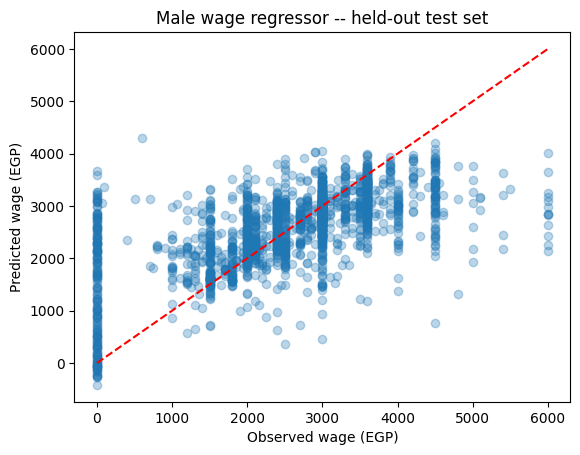

In [33]:
import matplotlib.pyplot as plt

plt.scatter(y_male_test, y_male_pred, alpha=0.3)
plt.plot([y_male_test.min(), y_male_test.max()], [y_male_test.min(), y_male_test.max()], "r--")
plt.xlabel("Observed wage (EGP)")
plt.ylabel("Predicted wage (EGP)")
plt.title("Male wage regressor -- held-out test set")
plt.show()

MALE WAGE REGRESSOR -- full results summary
Best hyperparameters: depth=8, learning_rate=0.1, l2_leaf_reg=10
Cross-validation R2 (during tuning): 0.3835

Sample sizes: n_train=7954 (80.0%), n_test=1989 (20.0%), n_total=9943

Metrics (raw wage, EGP):
  Train R2  = 0.5923
  Test R2   = 0.4019
  Test MAE  = 614.2 EGP
  Test RMSE = 905.2 EGP
  Mean-baseline test R2 (predicting the average wage for everyone) = -0.0000


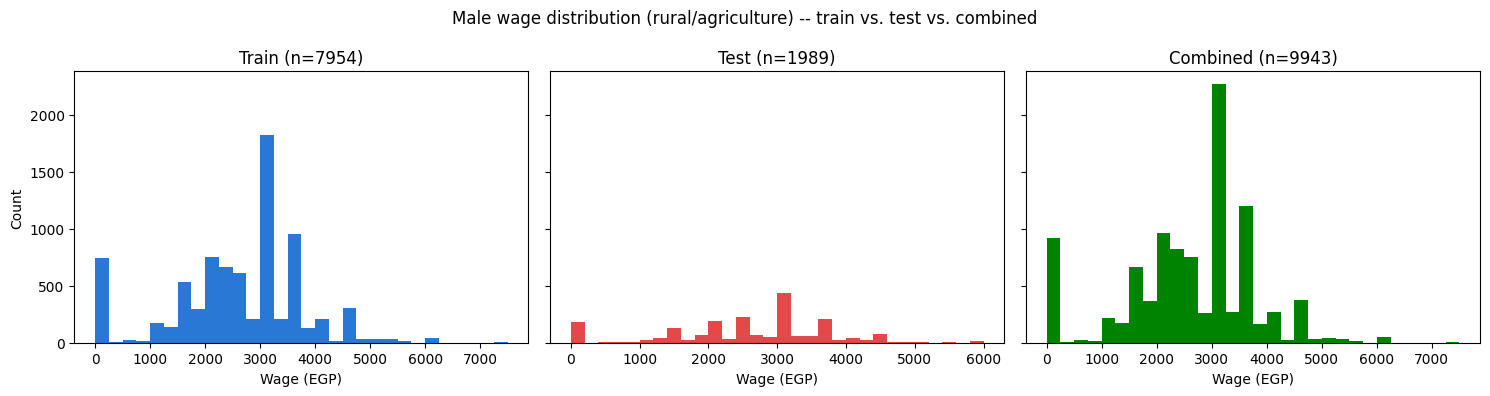

In [34]:
# ============================================================
# Male model -- full results summary: best hyperparameters, all metrics, sample sizes,
# and train/test/combined wage distributions
# ============================================================
print("MALE WAGE REGRESSOR -- full results summary")
print("=" * 60)
print(
    f"Best hyperparameters: depth={male_summary['best_depth']}, "
    f"learning_rate={male_summary['best_learning_rate']}, "
    f"l2_leaf_reg={male_summary['best_l2_leaf_reg']}"
)
print(f"Cross-validation R2 (during tuning): {male_summary['cv_best_r2']:.4f}")
print()
n_total = male_summary['n_train'] + male_summary['n_test']
print(
    f"Sample sizes: n_train={male_summary['n_train']} "
    f"({male_summary['n_train'] / n_total:.1%}), "
    f"n_test={male_summary['n_test']} ({male_summary['n_test'] / n_total:.1%}), "
    f"n_total={n_total}"
)
print()
print("Metrics (raw wage, EGP):")
print(f"  Train R2  = {male_summary['train_r2']:.4f}")
print(f"  Test R2   = {male_summary['test_r2']:.4f}")
print(f"  Test MAE  = {male_summary['test_mae']:.1f} EGP")
print(f"  Test RMSE = {male_summary['test_rmse']:.1f} EGP")
print(f"  Mean-baseline test R2 (predicting the average wage for everyone) = {male_summary['baseline_test_r2']:.4f}")

# Train vs. test vs. combined wage distribution -- checks the test set wasn't accidentally drawn
# from a different part of the wage distribution than train, and shows where most of the
# male rural/agriculture wage-earning population actually sits.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].hist(y_male_train, bins=30, color="#2a78d6")
axes[0].set_title(f"Train (n={len(y_male_train)})")
axes[1].hist(y_male_test, bins=30, color="#e34948")
axes[1].set_title(f"Test (n={len(y_male_test)})")
axes[2].hist(pd.concat([y_male_train, y_male_test]), bins=30, color="#008300")
axes[2].set_title(f"Combined (n={n_total})")
for ax in axes:
    ax.set_xlabel("Wage (EGP)")
axes[0].set_ylabel("Count")
fig.suptitle("Male wage distribution (rural/agriculture) -- train vs. test vs. combined")
plt.tight_layout()
plt.show()

<div style="font-size: 0.85em;">

### Experiment: combined over and under sampling

Same base as train-catboost_raw_with_zeros_augmented.ipynb (zeros included, emps and corrected_yield_pp dropped, RMSE loss), but that notebook only oversampled the positive-wage minority and showed real overfitting: train R2 0.887 vs test R2 0.520, positive-wage undershoot barely moved.

This version also drops 40% of the zero-wage training rows first, so the majority is less overwhelming before oversampling (a standard hybrid approach, similar to SMOTEENN and SMOTETomek). Male is left untouched: 91% of men are already positive-wage, so there is no imbalance to correct there.

Like Tweedie and plain oversampling, this changes how much weight different parts of the training data get. It cannot manufacture a feature that distinguishes the two groups where none exists. If the same undershoot pattern persists, that further confirms the problem is a missing feature, not the resampling scheme.

</div>

<div style="font-size: 0.85em;">

### Female model: predict wage level (raw wage in EGP, conditional on earning something)

Same structure as the male model on purpose: both predict wage level, not one classifier and one regressor, so a SHAP comparison between them is apples to apples. Matches the paper's own framing (Figure X compares SHAP-ranked predictors for men and women). Only respondents with totwag>0 are used, same as the male model.

</div>

In [35]:
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
# root_mean_squared_error needs sklearn>=1.4 -- use mean_squared_error ** 0.5 instead,
# which works on every sklearn version (confirmed: this environment has 1.3.0).
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
def root_mean_squared_error(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5
from catboost import CatBoostRegressor

# sex == '2' is Female (verified against survey_df).
final_sample_female = final_sample[final_sample['sex'] == '2']
# totwag==0 respondents INCLUDED here on purpose (see the markdown cell above) -- the sibling
# notebook train-catboost_raw.ipynb drops them; this is the only intentional difference.
final_sample_female = final_sample_female[final_sample_female['totwag'] < 10000]  # same outlier cap as _ori

X_female = final_sample_female[cols].drop(columns=['totwag', 'emps', 'corrected_yield_pp'])
y_female = final_sample_female['totwag']  # RAW wage, not log -- capped at <10000 above
female_cat_features = [c for c in categorical_columns if c in X_female.columns]

X_female_train, X_female_test, y_female_train, y_female_test = train_test_split(
    X_female, y_female, test_size=0.2, random_state=42,
)

from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler

def smogn_augment(X_train, y_train, cat_cols, k=5, n_synthetic=None, random_state=42):
    """SMOTE-NC/SMOGN-style synthetic oversampling of the positive-wage rows within a training
    set (Branco, Torgo & Ribeiro, 2017, "SMOGN: a Pre-processing Approach for Imbalanced
    Regression"). Interpolates between a real positive-wage row and one of its k nearest
    positive-wage neighbors (numeric features AND target together, so a synthetic row stays
    internally consistent), then adds proportional Gaussian jitter so synthetic rows aren't pure
    linear combinations of two real ones. Categorical columns are copied from whichever parent
    row the interpolation weight favors (can't numerically blend a category).
    Only ever called on X_train/y_train -- the test set is never touched, so synthetic rows
    can't leak into evaluation."""
    rng = np.random.default_rng(random_state)
    is_positive = (y_train > 0).to_numpy()
    minority_idx = np.where(is_positive)[0]
    if n_synthetic is None:
        n_synthetic = len(minority_idx)  # roughly doubles the positive-wage training rows -- a
        # starting choice, not a tuned one; worth revisiting if this direction looks promising

    num_cols = [c for c in X_train.columns if c not in cat_cols]
    X_min_num = X_train.iloc[minority_idx][num_cols].astype(float)
    X_min_cat = X_train.iloc[minority_idx][cat_cols] if cat_cols else None
    y_min = y_train.iloc[minority_idx].to_numpy()

    scaler = StandardScaler()
    X_min_scaled = scaler.fit_transform(X_min_num.fillna(X_min_num.median()))

    nn = NearestNeighbors(n_neighbors=min(k + 1, len(minority_idx)))
    nn.fit(X_min_scaled)
    _, neighbor_idx = nn.kneighbors(X_min_scaled)

    synth_num_rows, synth_cat_rows, synth_y = [], [], []
    for _ in range(n_synthetic):
        i = rng.integers(0, len(minority_idx))
        neighbors_of_i = neighbor_idx[i][1:]  # drop self (always the first/closest neighbor)
        j = rng.choice(neighbors_of_i)
        lam = rng.uniform(0, 1)

        num_i, num_j = X_min_num.iloc[i].to_numpy(), X_min_num.iloc[j].to_numpy()
        synth_num_rows.append(num_i + lam * (num_j - num_i))

        if cat_cols:
            synth_cat_rows.append(X_min_cat.iloc[i if lam < 0.5 else j].to_dict())

        y_i, y_j = y_min[i], y_min[j]
        synth_val = y_i + lam * (y_j - y_i)
        synth_val += rng.normal(0, 0.05 * max(synth_val, 1))  # proportional jitter
        synth_y.append(max(synth_val, 1.0))  # keep strictly positive -- this represents the paid subgroup

    synth_df = pd.DataFrame(synth_num_rows, columns=num_cols)
    if cat_cols:
        synth_cat_df = pd.DataFrame(synth_cat_rows)
        synth_df = pd.concat([synth_df.reset_index(drop=True), synth_cat_df.reset_index(drop=True)], axis=1)
    synth_df = synth_df[X_train.columns]
    synth_y = pd.Series(synth_y, name=y_train.name)

    X_aug = pd.concat([X_train.reset_index(drop=True), synth_df], ignore_index=True)
    y_aug = pd.concat([y_train.reset_index(drop=True), synth_y], ignore_index=True)
    print(
        f"  augmentation: {len(minority_idx)} real positive-wage rows -> +{n_synthetic} synthetic "
        f"-> {len(X_aug)} total training rows ({(~is_positive).sum()} zero unchanged)"
    )
    return X_aug, y_aug

def resample_combined(X_train, y_train, cat_cols, k=5, undersample_frac=0.685, oversample_n=None, random_state=42):
    """Hybrid resampling (cf. SMOTEENN/SMOTETomek): randomly drop `undersample_frac` of the
    zero-wage training rows first, THEN SMOGN-oversample the (now relatively larger) positive-wage
    rows via smogn_augment. Oversampling alone left a large train/test R2 gap (0.887 vs 0.520) --
    pure inflation of the minority didn't reduce how zero-dominated the training set still was.
    Dropping some of the majority directly addresses that, at the real cost of discarding actual
    data -- undersample_frac=0.4 is a moderate starting choice, not a tuned one."""
    rng = np.random.default_rng(random_state)
    is_zero = (y_train == 0).to_numpy()
    zero_idx = np.where(is_zero)[0]
    n_keep = int(len(zero_idx) * (1 - undersample_frac))
    keep_zero_idx = rng.choice(zero_idx, size=n_keep, replace=False)
    keep_idx = np.sort(np.concatenate([keep_zero_idx, np.where(~is_zero)[0]]))

    X_reduced = X_train.iloc[keep_idx].reset_index(drop=True)
    y_reduced = y_train.iloc[keep_idx].reset_index(drop=True)
    print(
        f"  undersampling: dropped {len(zero_idx) - n_keep} of {len(zero_idx)} zero-wage rows "
        f"({undersample_frac:.0%}) -> {len(zero_idx) - n_keep} + {(~is_zero).sum()} = {len(keep_idx)} rows before oversampling"
    )
    return smogn_augment(X_reduced, y_reduced, cat_cols=cat_cols, k=k, n_synthetic=oversample_n, random_state=random_state)

X_female_train, y_female_train = resample_combined(
    X_female_train, y_female_train, cat_cols=female_cat_features, k=5, undersample_frac=0.685,
)  # ~350 zero rows kept (moderate reduction, chosen over full match-to-bin-count to avoid discarding most real zero-wage data)

# loss_function is now part of the grid too -- comparing RMSE against Tweedie on top of
# the resampled/augmented training data, since neither alone (Tweedie on original data,
# augmentation with RMSE) fixed the zero/positive bias -- this checks whether combining
# both does better than either alone.
female_param_grid = {
    "depth": [4, 6, 8], "learning_rate": [0.03, 0.1], "l2_leaf_reg": [3, 10, 30],
    "loss_function": ["RMSE", "Tweedie:variance_power=1.1", "Tweedie:variance_power=1.5", "Tweedie:variance_power=1.9"],
}
female_cv = KFold(n_splits=3, shuffle=True, random_state=42)

female_search = GridSearchCV(
    estimator=CatBoostRegressor(
        iterations=300, random_seed=42, verbose=False,
    ),
    param_grid=female_param_grid,
    scoring="r2",
    cv=female_cv,
    refit=True,
    verbose=2,  # prints per-fold/candidate progress -- otherwise a multi-minute search looks hung
)
female_search.fit(X_female_train, y_female_train, cat_features=female_cat_features)

# Same early-stopped refit as the male model. Caveat worth flagging: with only ~325 female
# training rows, a 15% validation carve-out leaves a small (~50-row) validation set, so the
# early-stopping point itself carries more noise here than for the male model.
X_female_fit, X_female_val, y_female_fit, y_female_val = train_test_split(
    X_female_train, y_female_train, test_size=0.15, random_state=42,
)
female_model = CatBoostRegressor(
    iterations=5000, random_seed=42, verbose=False, **female_search.best_params_,
)
female_model.fit(
    X_female_fit, y_female_fit, eval_set=(X_female_val, y_female_val), cat_features=female_cat_features,
    use_best_model=True, early_stopping_rounds=200,
)
y_female_pred = female_model.predict(X_female_test)
print(f"  final refit used {female_model.get_best_iteration()} iterations (of a 5000 ceiling, early-stopped)")

female_grid_rows = [
    {
        "model": "female_wage_regressor",
        "depth": p["depth"],
        "learning_rate": p["learning_rate"],
        "l2_leaf_reg": p["l2_leaf_reg"],
        "loss_function": p["loss_function"],
        "cv_mean_r2": mean_s,
        "cv_std_r2": std_s,
        "is_best": p == female_search.best_params_,
    }
    for p, mean_s, std_s in zip(
        female_search.cv_results_["params"],
        female_search.cv_results_["mean_test_score"],
        female_search.cv_results_["std_test_score"],
    )
]

female_baseline_pred = np.repeat(y_female_train.mean(), len(y_female_test))

female_summary = {
    "model": "female_wage_regressor",
    "best_depth": female_search.best_params_["depth"],
    "best_learning_rate": female_search.best_params_["learning_rate"],
    "best_l2_leaf_reg": female_search.best_params_["l2_leaf_reg"],
    "best_loss_function": female_search.best_params_["loss_function"],
    "cv_best_r2": female_search.best_score_,
    "test_r2": r2_score(y_female_test, y_female_pred),
    "test_mae": mean_absolute_error(y_female_test, y_female_pred),
    "test_rmse": root_mean_squared_error(y_female_test, y_female_pred),
    "train_r2": r2_score(y_female_train, female_model.predict(X_female_train)),
    "baseline_test_r2": r2_score(y_female_test, female_baseline_pred),
    "baseline_test_rmse": root_mean_squared_error(y_female_test, female_baseline_pred),
    "n_train": len(X_female_train),
    "n_test": len(X_female_test),
}
print(
    f"Female regressor -- best depth={female_summary['best_depth']}, "
    f"lr={female_summary['best_learning_rate']}, l2={female_summary['best_l2_leaf_reg']}, "
    f"loss={female_summary['best_loss_function']}"
)
print(
    f"  test R2={female_summary['test_r2']:.4f} (mean-baseline {female_summary['baseline_test_r2']:.4f}), "
    f"train R2={female_summary['train_r2']:.4f}"
)
print(
    f"  NOTE: totwag==0 respondents are INCLUDED in this notebook ({len(X_female)} female rows "
    f"total, vs 405 when zeros are dropped in train-catboost_raw.ipynb) -- if test R2 here is "
    f"much higher than 0.1879, check whether emps is doing the work (see markdown cell above) "
    f"before treating this as a real wage-level improvement."
)

# Same zero/positive bias check as the Tweedie experiment -- does augmenting the positive-wage
# minority reduce the overshoot-at-zero / undershoot-at-positive pattern, or does it leave the
# loss-function mismatch untouched (expected, if the diagnosis that this is a distributional
# problem rather than a sample-size problem holds)?
aug_pred_at_zero = y_female_pred[(y_female_test == 0).to_numpy()]
aug_pred_at_pos = y_female_pred[(y_female_test > 0).to_numpy()]
print(f"  mean predicted, true zeros    : {aug_pred_at_zero.mean():.1f} EGP (n={len(aug_pred_at_zero)})")
print(
    f"  mean predicted, true positive : {aug_pred_at_pos.mean():.1f} EGP vs actual "
    f"{y_female_test[y_female_test > 0].mean():.1f} EGP (n={len(aug_pred_at_pos)})"
)

  undersampling: dropped 762 of 1112 zero-wage rows (68%) -> 762 + 317 = 667 rows before oversampling
  augmentation: 317 real positive-wage rows -> +317 synthetic -> 984 total training rows (350 zero unchanged)
Fitting 3 folds for each of 72 candidates, totalling 216 fits
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=  10.7s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=   9.4s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=RMSE; total time=   9.5s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=   9.3s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=   9.6s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.1; total time=  10.1s
[CV] END depth=4, l2_leaf_reg=3, learning_rate=0.03, loss_function=Tweedie:variance_power=1.5; total time=  

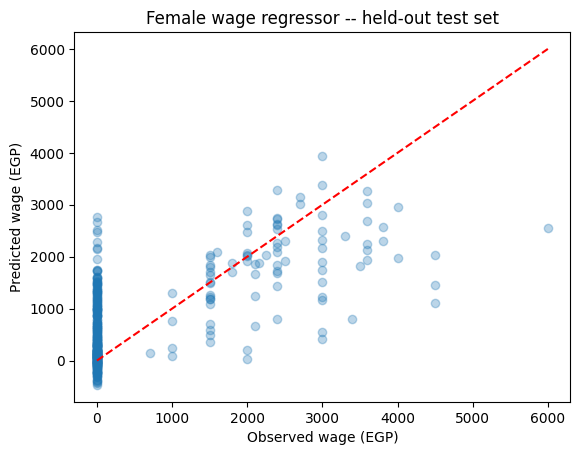

In [36]:
import matplotlib.pyplot as plt

plt.scatter(y_female_test, y_female_pred, alpha=0.3)
plt.plot([y_female_test.min(), y_female_test.max()], [y_female_test.min(), y_female_test.max()], "r--")
plt.xlabel("Observed wage (EGP)")
plt.ylabel("Predicted wage (EGP)")
plt.title("Female wage regressor -- held-out test set")
plt.show()

FEMALE WAGE REGRESSOR -- full results summary
Best hyperparameters: depth=8, learning_rate=0.1, l2_leaf_reg=3
Cross-validation R2 (during tuning): 0.5730

Sample sizes: n_train=984 (73.3%), n_test=358 (26.7%), n_total=1342

Metrics (raw wage, EGP):
  Train R2  = 0.8985
  Test R2   = 0.4071
  Test MAE  = 614.8 EGP
  Test RMSE = 891.1 EGP
  Mean-baseline test R2 (predicting the average wage for everyone) = -0.5286


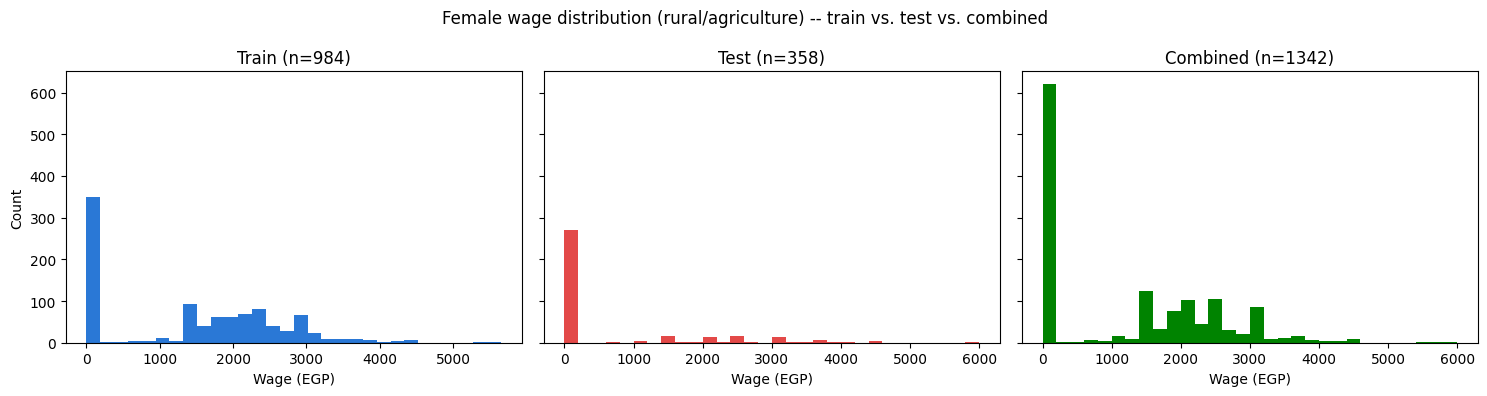

In [37]:
# ============================================================
# Female model -- full results summary: best hyperparameters, all metrics, sample sizes,
# and train/test/combined wage distributions
# ============================================================
print("FEMALE WAGE REGRESSOR -- full results summary")
print("=" * 60)
print(
    f"Best hyperparameters: depth={female_summary['best_depth']}, "
    f"learning_rate={female_summary['best_learning_rate']}, "
    f"l2_leaf_reg={female_summary['best_l2_leaf_reg']}"
)
print(f"Cross-validation R2 (during tuning): {female_summary['cv_best_r2']:.4f}")
print()
n_total = female_summary['n_train'] + female_summary['n_test']
print(
    f"Sample sizes: n_train={female_summary['n_train']} "
    f"({female_summary['n_train'] / n_total:.1%}), "
    f"n_test={female_summary['n_test']} ({female_summary['n_test'] / n_total:.1%}), "
    f"n_total={n_total}"
)
print()
print("Metrics (raw wage, EGP):")
print(f"  Train R2  = {female_summary['train_r2']:.4f}")
print(f"  Test R2   = {female_summary['test_r2']:.4f}")
print(f"  Test MAE  = {female_summary['test_mae']:.1f} EGP")
print(f"  Test RMSE = {female_summary['test_rmse']:.1f} EGP")
print(f"  Mean-baseline test R2 (predicting the average wage for everyone) = {female_summary['baseline_test_r2']:.4f}")

# Train vs. test vs. combined wage distribution -- checks the test set wasn't accidentally drawn
# from a different part of the wage distribution than train, and shows where most of the
# female rural/agriculture wage-earning population actually sits.
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
axes[0].hist(y_female_train, bins=30, color="#2a78d6")
axes[0].set_title(f"Train (n={len(y_female_train)})")
axes[1].hist(y_female_test, bins=30, color="#e34948")
axes[1].set_title(f"Test (n={len(y_female_test)})")
axes[2].hist(pd.concat([y_female_train, y_female_test]), bins=30, color="#008300")
axes[2].set_title(f"Combined (n={n_total})")
for ax in axes:
    ax.set_xlabel("Wage (EGP)")
axes[0].set_ylabel("Count")
fig.suptitle("Female wage distribution (rural/agriculture) -- train vs. test vs. combined")
plt.tight_layout()
plt.show()

In [ ]:
# Before vs. after resampling -- zero-wage and positive-wage row counts in the female
# training set. Before is fixed by the seed=42 command-unit draw (1112 zero, 317 positive,
# never resampled). After is read directly from y_female_train, which by this point already
# holds the post-resampling state set earlier in the female fit cell above.
before = {"Zero": 1112, "Positive": 317}
after = {
    "Zero": int((y_female_train == 0).sum()),
    "Positive": int((y_female_train > 0).sum()),
}
labels = ["Zero", "Positive"]
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x - width/2, [before[l] for l in labels], width, label="Before resampling", color="#e34948")
ax.bar(x + width/2, [after[l] for l in labels], width, label="After resampling", color="#2a78d6")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("Count")
ax.set_title("Female training set: before vs. after resampling")
ax.legend()
for i, l in enumerate(labels):
    ax.text(i - width/2, before[l] + 15, str(before[l]), ha="center")
    ax.text(i + width/2, after[l] + 15, str(after[l]), ha="center")
plt.tight_layout()
plt.show()

print(f"Before: zero:positive = {before['Zero']/before['Positive']:.2f} : 1")
print(f"After:  zero:positive = {after['Zero']/after['Positive']:.2f} : 1")

In [38]:
male_imp = pd.Series(male_model.feature_importances_, index=X_male_train.columns).sort_values(ascending=False)
female_imp = pd.Series(female_model.feature_importances_, index=X_female_train.columns).sort_values(ascending=False)

print("Top 15 male wage regressor feature importances:")
print(male_imp.head(15))
print()
print("Top 15 female wage regressor feature importances:")
print(female_imp.head(15))

Top 15 male wage regressor feature importances:
empstab                           12.761742
hrswk                              9.073896
tenure                             7.440920
female_violence_sexual             6.246267
age                                6.030455
rel                                5.579424
occ                                5.178462
female_child_married               4.451778
n_other_employed                   4.397665
mart_d                             4.122843
yeduc                              2.424869
female_contraceptives_decision     2.111878
female_healthcare_decision         1.806516
household_size                     1.589102
precipitation                      1.384753
dtype: float64

Top 15 female wage regressor feature importances:
empstab                       18.597125
hrswk                          8.436252
n_other_employed               7.404569
tenure                         6.576042
rel                            6.173765
age                       

Male wage regressor -- SHAP summary (rural/agriculture):


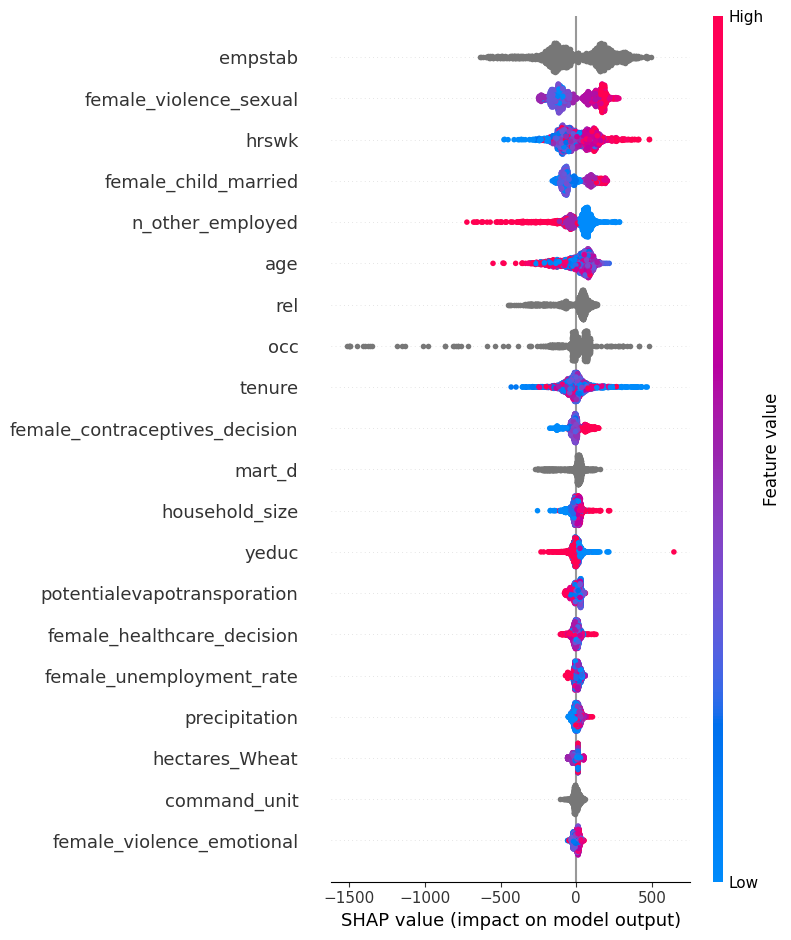

Female wage regressor -- SHAP summary (rural/agriculture):


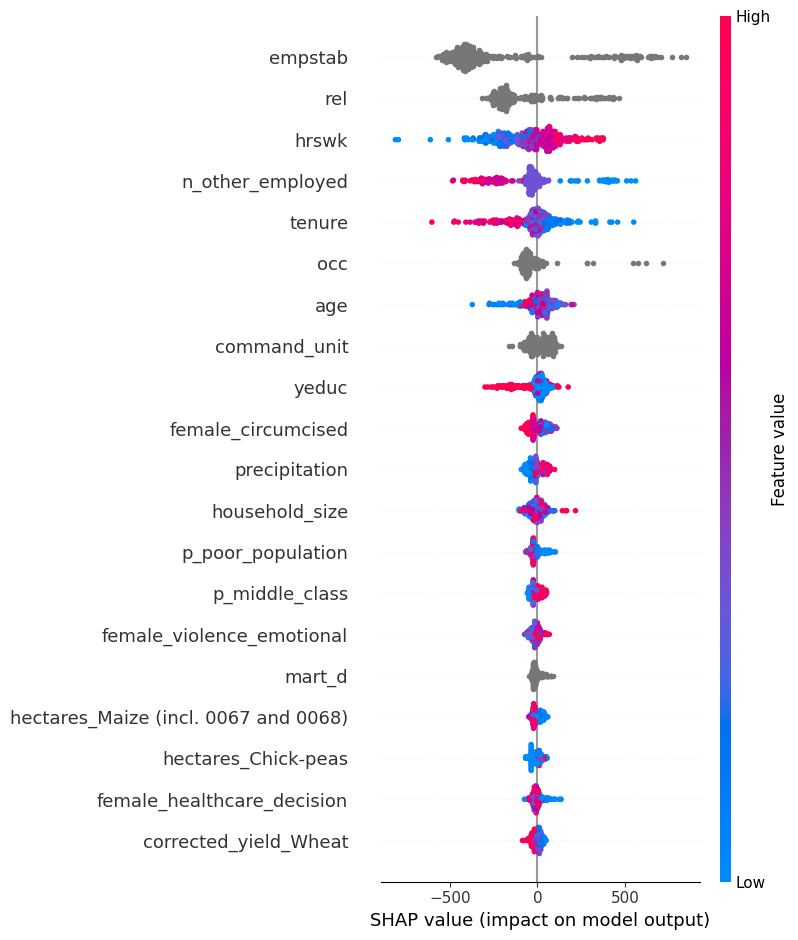

In [39]:
# SHAP comparison for both genders -- the paper's actual stated deliverable (Figure X:
# "Comparison of SHAP values for men and women across the 10 highest SHAP-ranked predictors").
# Not present in this notebook before -- added here to match the full-survey version.
import shap

male_explainer = shap.TreeExplainer(male_model)
male_shap_values = male_explainer.shap_values(X_male_test)

female_explainer = shap.TreeExplainer(female_model)
female_shap_values = female_explainer.shap_values(X_female_test)

print("Male wage regressor -- SHAP summary (rural/agriculture):")
shap.summary_plot(male_shap_values, X_male_test, show=True)

print("Female wage regressor -- SHAP summary (rural/agriculture):")
shap.summary_plot(female_shap_values, X_female_test, show=True)

In [40]:
# Save every hyperparameter combination tried (not just the winner) plus the final summary
# metrics for both models -- fully reproducible: every random seed is fixed (command-unit
# assignment rng=42, both train_test_splits random_state=42, both GridSearchCV KFold
# random_state=42, both CatBoost random_seed=42).
male_grid_df = pd.DataFrame(male_grid_rows)
female_grid_df = pd.DataFrame(female_grid_rows)
model_summary_df = pd.DataFrame([male_summary, female_summary])

male_grid_df.to_csv(RESULT_DIR / "male_regressor_grid_search_COMBINED_TWEEDIE.csv", index=False)
female_grid_df.to_csv(RESULT_DIR / "female_regressor_grid_search_COMBINED_TWEEDIE.csv", index=False)
model_summary_df.to_csv(RESULT_DIR / "model_summary_metrics_COMBINED_TWEEDIE.csv", index=False)

print(f"Saved grid-search + summary metrics to {RESULT_DIR}")
model_summary_df

Saved grid-search + summary metrics to d:\KARISMA\POST GRADUATE\UT\Intership\Deltares\GITHUB\egypt-survey-ml\ERF_Data\Data\04_Data\Result


,model,best_depth,best_learning_rate,best_l2_leaf_reg,best_loss_function,cv_best_r2,test_r2,test_mae,test_rmse,train_r2,baseline_test_r2,baseline_test_rmse,n_train,n_test
0,male_wage_regressor,8,0.1,10,RMSE,0.383478,0.401926,614.153963,905.178768,0.592315,-0.000003,1170.462494,7954,1989
1,female_wage_regressor,8,0.1,3,RMSE,0.572985,0.407078,614.826479,891.123859,0.898470,-0.528618,1430.832466,984,358


In [41]:
print("mean predicted, true zeros:", y_male_pred[y_male_test == 0].mean())
print("mean predicted, true positive:", y_male_pred[y_male_test > 0].mean(), "vs actual:", y_male_test[y_male_test > 0].mean())


mean predicted, true zeros: 1445.7233043002138
mean predicted, true positive: 2681.3790965085104 vs actual: 2799.171538868174
